In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud transformers torch openpyxl Sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 18.2 MB/s eta 0:00:00


In [ ]:
# 2. Imports & Integrasi Google Drive

import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from wordcloud import WordCloud

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IS_COLAB = True
except:
    IS_COLAB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Mounted at /content/drive


In [ ]:
# Ganti path ini sesuai lokasi file Anda
FILE_PATH = '/content/drive/MyDrive/Data/dataset_mbg1.csv'

try:
    df = pd.read_csv(FILE_PATH)
    print(f"Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
    print(df.head(3))
except FileNotFoundError:
    print("File tidak ditemukan! Membuat dummy data untuk demonstrasi...")
    data = {
        'full_text': [
            "Program MBG ini sangat membantu anak-anak sekolah!",
            "Makan siangnya basi, parah banget pengelolaannya.",
            "Biasa aja sih, menunya standar.",
            "Semoga program ini lanjut terus, terima kasih pak presiden.",
            "Anggaran besar tapi kualitas makanan nol besar! kecewa."
        ]
    }
    df = pd.DataFrame(data)
    print("Dummy data dibuat.")

Data berhasil dimuat: 1000 baris, 15 kolom
   conversation_id_str                      created_at  favorite_count  \
0         2.013081e+18  Mon Jan 19 07:22:35 +0000 2026             0.0   
1         2.011709e+18  Thu Jan 15 07:56:11 +0000 2026             1.0   
2         2.013417e+18  Tue Jan 20 01:03:52 +0000 2026             0.0   

                                           full_text        id_str lang  \
0  @brutalouttahere Boleh bingit #SobatRupiah! Pe...  2.013150e+18   in   
1  🇨🇳 #China | *#PBOC TO BOOST RELENDING QUOTA FO...  2.011709e+18   en   
2  MBG harganya anggaran pendidikan dan kesehatan...  2.013417e+18   in   

   location  quote_count  reply_count  retweet_count tweet_url   user_id_str  \
0       NaN          0.0          0.0            0.0       NaN  1.536671e+08   
1       NaN          0.0          0.0            1.0       NaN  5.371756e+08   
2       NaN          0.0          0.0            0.0       NaN  1.434456e+18   

  username  tweet_id_clean            

In [ ]:
# =========================================
# 1. CEK DATA AWAL
# =========================================

print("Jumlah data awal:", len(df))
print("Kolom dataset:", df.columns)

df.head()

Jumlah data awal: 1000
Kolom dataset: Index(['conversation_id_str', 'created_at', 'favorite_count', 'full_text',
       'id_str', 'lang', 'location', 'quote_count', 'reply_count',
       'retweet_count', 'tweet_url', 'user_id_str', 'username',
       'tweet_id_clean', 'fallback_key'],
      dtype='object')


,conversation_id_str,created_at,favorite_count,full_text,id_str,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,tweet_id_clean,fallback_key
0,2.013081e+18,Mon Jan 19 07:22:35 +0000 2026,0.0,@brutalouttahere Boleh bingit #SobatRupiah! Pe...,2.013150e+18,in,NaN,0.0,0.0,0.0,NaN,1.536671e+08,NaN,2.013150e+18,@brutalouttahere Boleh bingit #SobatRupiah! Pe...
1,2.011709e+18,Thu Jan 15 07:56:11 +0000 2026,1.0,🇨🇳 #China | *#PBOC TO BOOST RELENDING QUOTA FO...,2.011709e+18,en,NaN,0.0,0.0,1.0,NaN,5.371756e+08,NaN,2.011709e+18,🇨🇳 #China | *#PBOC TO BOOST RELENDING QUOTA FO...
2,2.013417e+18,Tue Jan 20 01:03:52 +0000 2026,0.0,MBG harganya anggaran pendidikan dan kesehatan...,2.013417e+18,in,NaN,0.0,0.0,0.0,NaN,1.434456e+18,NaN,2.013417e+18,MBG harganya anggaran pendidikan dan kesehatan...
3,2.011658e+18,Thu Jan 15 04:32:30 +0000 2026,1.0,@apoorv_bh89 @WeaveGrid @SCE @Tesla I didn't g...,2.011658e+18,en,NaN,0.0,1.0,1.0,NaN,1.927497e+07,NaN,2.011658e+18,@apoorv_bh89 @WeaveGrid @SCE @Tesla I didn't g...
4,2.011382e+18,Wed Jan 14 10:17:20 +0000 2026,0.0,Dari awal masuk KKN sampe hari ini gua belum m...,2.011382e+18,in,NaN,0.0,1.0,0.0,NaN,1.996191e+18,NaN,2.011382e+18,Dari awal masuk KKN sampe hari ini gua belum m...


In [ ]:
# =========================================
# 2. SELEKSI KOLOM TEKS
# =========================================

df_clean = df.copy()

df_clean = df_clean[['full_text']].dropna()
df_clean = df_clean.drop_duplicates(subset=['full_text']).reset_index(drop=True)

print("Jumlah data setelah hapus kosong dan duplikat:", len(df_clean))
df_clean.head()

Jumlah data setelah hapus kosong dan duplikat: 1000


,full_text
0,@brutalouttahere Boleh bingit #SobatRupiah! Pe...
1,🇨🇳 #China | *#PBOC TO BOOST RELENDING QUOTA FO...
2,MBG harganya anggaran pendidikan dan kesehatan...
3,@apoorv_bh89 @WeaveGrid @SCE @Tesla I didn't g...
4,Dari awal masuk KKN sampe hari ini gua belum m...


In [ ]:
# =========================================
# 3. PREPROCESSING UNTUK INDOBERTWEET
# =========================================

norm_dict = {
    'bgt': 'banget',
    'ga': 'tidak',
    'gak': 'tidak',
    'nggak': 'tidak',
    'g': 'tidak',
    'tdk': 'tidak',
    'yg': 'yang',
    'dlu': 'dulu',
    'kalo': 'kalau',
    'klo': 'kalau',
    'knp': 'kenapa',
    'bkn': 'bukan',
    'udh': 'sudah',
    'sdh': 'sudah',
    'dah': 'sudah',
    'jgn': 'jangan',
    'aja': 'saja',
    'tpi': 'tapi',
    'tp': 'tapi',
    'krn': 'karena',
    'utk': 'untuk',
    'u': 'aku',
    'dpt': 'dapat',
    'lg': 'lagi',
    'trs': 'terus',
    'kek': 'kayak',
    'gw': 'aku',
    'gue': 'aku',
    'gua': 'aku',
    'pd': 'pada',
    'mbg': 'makan bergizi gratis'
}

def normalize_text(text):
    words = str(text).split()
    words = [norm_dict.get(word, word) for word in words]
    return " ".join(words)

def clean_text_indobertweet(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '@USER', text)

    # hashtag: simbol # dihapus, kata tetap dipertahankan
    text = re.sub(r'#', '', text)

    # karakter HTML umum
    text = re.sub(r'&amp;', 'dan', text)

    # hapus karakter aneh berulang, tetapi jangan terlalu agresif
    text = re.sub(r'\s+', ' ', text).strip()

    text = normalize_text(text)

    return text

df_clean['text_clean'] = df_clean['full_text'].apply(clean_text_indobertweet)

print("Preprocessing IndoBERTweet selesai.")
df_clean[['full_text', 'text_clean']].head()

Preprocessing IndoBERTweet selesai.


,full_text,text_clean
0,@brutalouttahere Boleh bingit #SobatRupiah! Pe...,@USER boleh bingit sobatrupiah! permohonan mag...
1,🇨🇳 #China | *#PBOC TO BOOST RELENDING QUOTA FO...,🇨🇳 china | *pboc to boost relending quota for ...
2,MBG harganya anggaran pendidikan dan kesehatan...,makan bergizi gratis harganya anggaran pendidi...
3,@apoorv_bh89 @WeaveGrid @SCE @Tesla I didn't g...,@USER @USER @USER @USER i didn't get it at fir...
4,Dari awal masuk KKN sampe hari ini gua belum m...,dari awal masuk kkn sampe hari ini aku belum m...


In [ ]:
# =========================================
# 4. CEK HASIL PREPROCESSING
# =========================================

print("Jumlah data setelah preprocessing:", len(df_clean))
print("Jumlah teks kosong:", (df_clean['text_clean'].str.strip() == "").sum())

df_clean[['full_text', 'text_clean']].sample(10, random_state=42)

Jumlah data setelah preprocessing: 1000
Jumlah teks kosong: 4


,full_text,text_clean
521,@On_Veera nice program,@USER nice program
737,Of course the Russians have and had their own ...,of course the russians have and had their own ...
740,cortis sedang memasak memasak mbg tp kyknya,cortis sedang memasak memasak makan bergizi gr...
660,@rajapeanutbuter @B3doel___ Belum soalnya aku ...,@USER @USER belum soalnya aku ai dan tidak but...
411,Affordable Housing Program is creating stable ...,affordable housing program is creating stable ...
678,SY-Stem 2026 brings two outstanding keynote sp...,sy-stem 2026 brings two outstanding keynote sp...
626,Embu s estate offers 1- and 2-bedroom units wi...,embu s estate offers 1- and 2-bedroom units wi...
513,Prabowo arahan Percepatan Pembangunan Papua me...,prabowo arahan percepatan pembangunan papua me...
859,Melalui program Sekolah Rakyat Presiden Prabow...,melalui program sekolah rakyat presiden prabow...
136,@krod_123 @agent_of_change read about this &am...,@USER @USER read about this dan how kennedy su...


In [ ]:
df_clean = df_clean[df_clean['text_clean'].str.strip() != ""].reset_index(drop=True)

print("Jumlah data final setelah menghapus teks kosong:", len(df_clean))

Jumlah data final setelah menghapus teks kosong: 996


In [ ]:
print(df_clean.columns)

Index(['full_text', 'text_clean'], dtype='object')


In [ ]:
MODEL_NAME = "Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cuda


In [ ]:
from tqdm import tqdm

texts = df_clean['text_clean'].astype(str).tolist()

batch_size = 32
labels = []
confidences = []

for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    preds = torch.argmax(probs, dim=1).cpu().numpy()
    confs = torch.max(probs, dim=1).values.cpu().numpy()

    for p, c in zip(preds, confs):
        if p == 0:
            labels.append("negatif")
        elif p == 1:
            labels.append("netral")
        else:
            labels.append("positif")

        confidences.append(c)

df_clean['label'] = labels
df_clean['confidence'] = confidences

100%|██████████| 32/32 [00:06<00:00,  4.95it/s]


In [ ]:
df_clean['label'].value_counts()

,count
label,
positif,421
netral,358
negatif,217


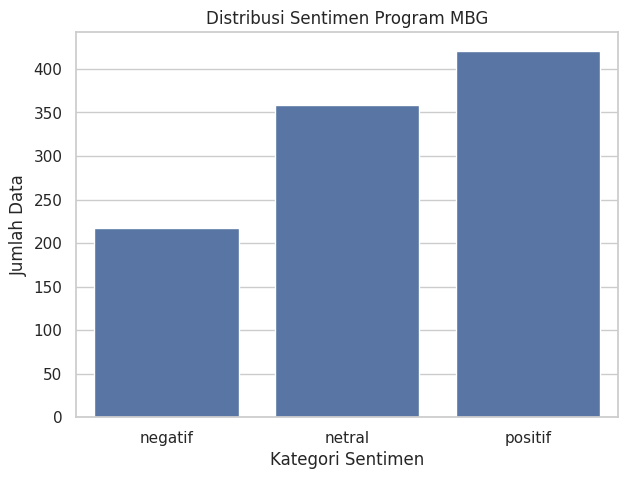

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.countplot(
    data=df_clean,
    x='label',
    order=['negatif', 'netral', 'positif']
)
plt.title("Distribusi Sentimen Program MBG")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Data")
plt.show()

In [ ]:
df_clean.to_csv("hasil_labeling_mbg_indobertweet.csv", index=False)

In [ ]:
#encode label menjadi angka
label_map = {
    "negatif": 0,
    "netral": 1,
    "positif": 2
}

df_clean['label_id'] = df_clean['label'].map(label_map)

df_clean[['text_clean', 'label', 'label_id']].head()

,text_clean,label,label_id
0,@USER boleh bingit sobatrupiah! permohonan mag...,netral,1
1,🇨🇳 china | *pboc to boost relending quota for ...,netral,1
2,makan bergizi gratis harganya anggaran pendidi...,negatif,0
3,@USER @USER @USER @USER i didn't get it at fir...,positif,2
4,dari awal masuk kkn sampe hari ini aku belum m...,positif,2


In [ ]:
#split data 70:15:15
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_clean['text_clean'].tolist(),
    df_clean['label_id'].tolist(),
    test_size=0.30,
    random_state=42,
    stratify=df_clean['label_id']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Data latih:", len(train_texts))
print("Data validasi:", len(val_texts))
print("Data uji:", len(test_texts))

Data latih: 697
Data validasi: 149
Data uji: 150


In [ ]:
#tokenisasi untuk training
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
#buat dataset Pytorch
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset   = SentimentDataset(val_encodings, val_labels)
test_dataset  = SentimentDataset(test_encodings, test_labels)

In [ ]:
#load model untuk klasifikasi
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

MODEL_NAME = "Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)


def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='weighted',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

training_args = TrainingArguments(
    output_dir='./hasil_indobertweet_mbg',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model='f1'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.259988,0.885906,0.895973,0.885906,0.884320
2,No log,0.324238,0.859060,0.873634,0.859060,0.854249
3,No log,0.334271,0.912752,0.921980,0.912752,0.910718
4,No log,0.355665,0.899329,0.906931,0.899329,0.897157


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=176, training_loss=0.266406774520874, metrics={'train_runtime': 135.4733, 'train_samples_per_second': 20.58, 'train_steps_per_second': 1.299, 'total_flos': 183390052156416.0, 'train_loss': 0.266406774520874, 'epoch': 4.0})

In [ ]:
#evaluasi pada data uji
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = np.array(test_labels)

In [ ]:
#clasification Repist
from sklearn.metrics import classification_report, accuracy_score

target_names = ["negatif", "netral", "positif"]

print("Accuracy:", accuracy_score(y_true, y_pred))

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
))

Accuracy: 0.92
              precision    recall  f1-score   support

     negatif     1.0000    0.7273    0.8421        33
      netral     0.8983    0.9815    0.9381        54
     positif     0.9104    0.9683    0.9385        63

    accuracy                         0.9200       150
   macro avg     0.9363    0.8923    0.9062       150
weighted avg     0.9258    0.9200    0.9171       150



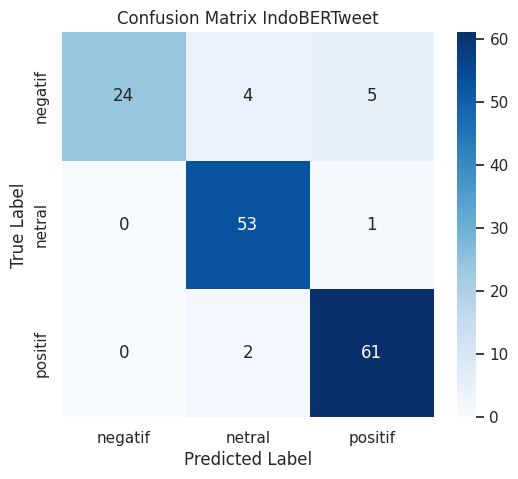

In [ ]:
#confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix IndoBERTweet")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
#simpan model
trainer.save_model("./model_indobertweet_mbg")
tokenizer.save_pretrained("./model_indobertweet_mbg")

In [ ]:
#word cloud per sentimen
from wordcloud import WordCloud

for label in ["negatif", "netral", "positif"]:
    text = " ".join(df_clean[df_clean["label"] == label]["text_clean"])

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud Sentimen {label.capitalize()}")
    plt.show()